In [105]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

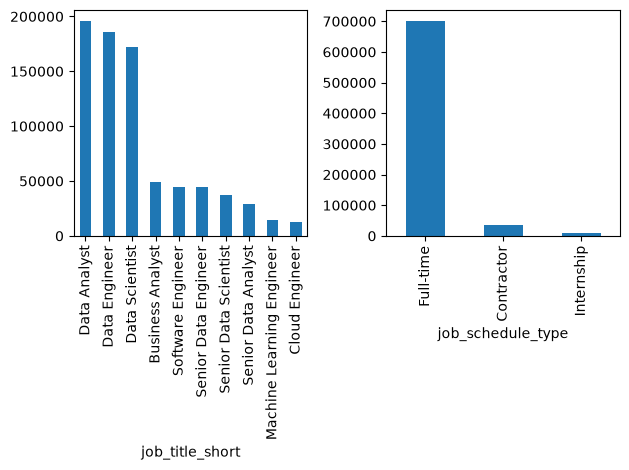

In [ ]:
#fig, ax = plt.subplots() #plotting a 2x2 plot area

#df['job_title_short'].value_counts().plot(kind = 'bar', ax = ax)  #Specify the ax

#Now lets do 2 plots

fig, ax = plt.subplots(1, 2)

df['job_title_short'].value_counts().plot(kind='bar', ax=ax[0])                #Pandas method
df['job_schedule_type'].value_counts().head(3).plot(kind='bar', ax=ax[1])       #Specify the index of an ax

#Fix the overlapping numbers

fig.tight_layout()


fig, ax = plt.subplots(1, 2)

ax[0].bar(df['job_title_short'].value_counts().index, df['job_title_short'].value_counts())                                    #Matplotlib method
ax[1].bar(df['job_schedule_type'].value_counts().head(3).index, df['job_schedule_type'].value_counts().head(3))

fig.tight_layout()

plt.show()

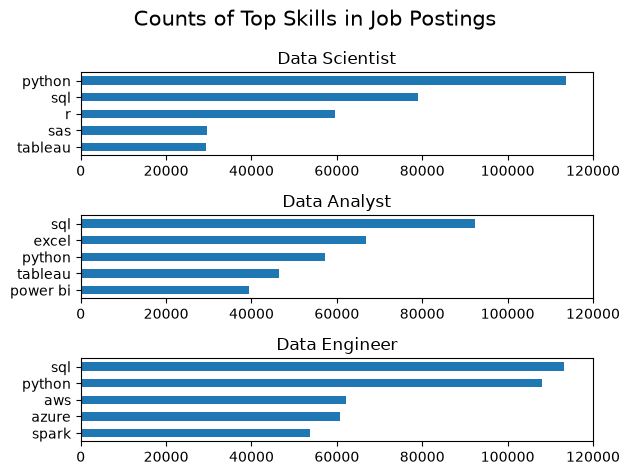

In [32]:
#Example: Count of Top Skills in Job Postings for each position
df_skills = df.copy()
df_skills = df_skills.explode('job_skills')
skills_count = df_skills.groupby(['job_skills', 'job_title_short']).size()
df_skills_count = skills_count.reset_index(name='skill_count')
df_skills_count.sort_values(by='skill_count', ascending=False, inplace=True)
df_skills_count

job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer']
fig, ax = plt.subplots(3, 1)
for i, job_title in enumerate(job_titles):
   df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
   df_plot.plot(kind = 'barh', x = 'job_skills', y = 'skill_count', ax = ax[i], title = job_title)
   ax[i].invert_yaxis()
   ax[i].set_ylabel('')
   ax[i].legend().set_visible(False)
   ax[i].set_xlim(0,120000)

fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
plt.tight_layout()

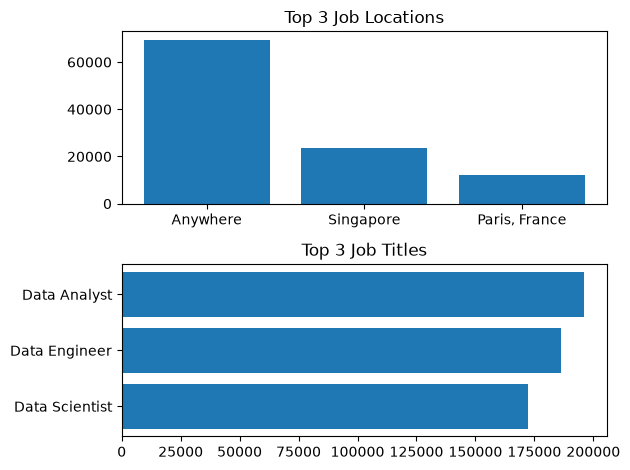

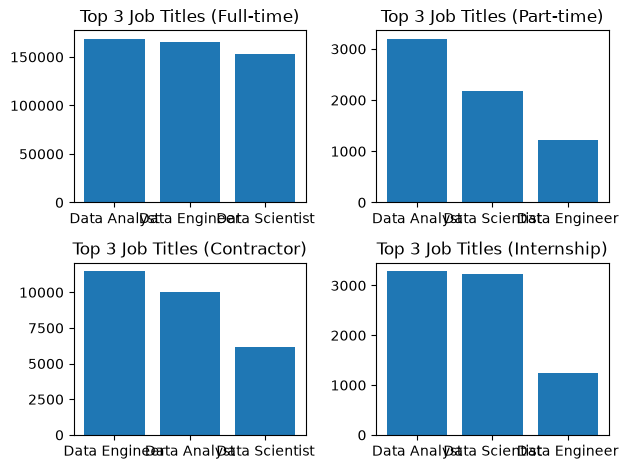

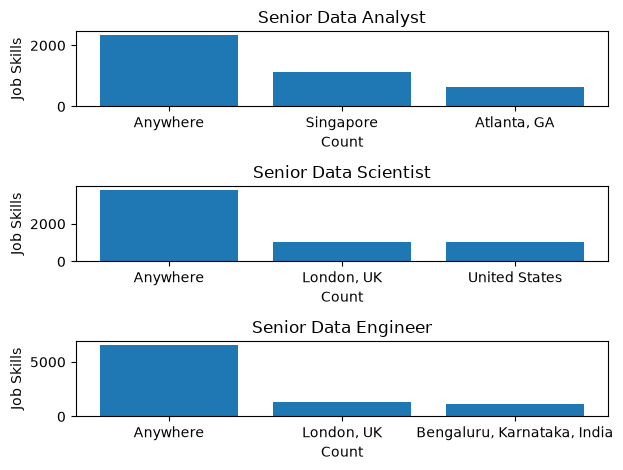

In [42]:
# PRACTICE PROBLEMS
fig, ax = plt.subplots(2, 1)
job_locations = df['job_location'].value_counts().head(3)
ax[0].bar(job_locations.index, job_locations.values)
ax[0].set_title('Top 3 Job Locations')
job_titles = df['job_title_short'].value_counts().head(3)
ax[1].barh(job_titles.index, job_titles.values)
ax[1].set_title('Top 3 Job Titles')
ax[1].invert_yaxis()
fig.tight_layout()

schedules = ['Full-time', 'Part-time', 'Contractor', 'Internship']
fig, ax = plt.subplots(2, 2)
for i, schedule in enumerate(schedules):
    df_schedule = df[df['job_schedule_type'] == schedule]['job_title_short'].value_counts().head(3)
    ax[i//2, i%2].bar( df_schedule.index,  df_schedule.values)
    ax[i//2, i%2].set_title(f'Top 3 Job Titles ({schedule})')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(3, 1)
job_roles = ['Senior Data Analyst', 'Senior Data Scientist', 'Senior Data Engineer']
for i, role in enumerate(job_roles):
    df_role = df[df['job_title_short'] == role]['job_location'].value_counts().head(3)
    ax[i].bar(df_role.index, df_role.values)
    ax[i].set_title(role)
    ax[i].set_xlabel('Count')
    ax[i].set_ylabel('Job Skills')
fig.tight_layout()
plt.show()

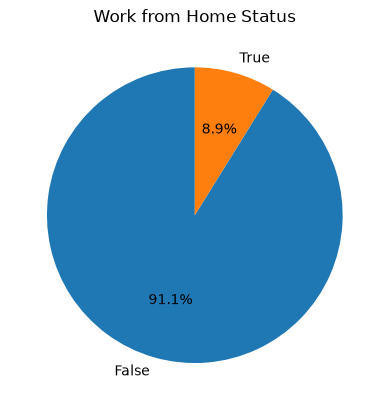

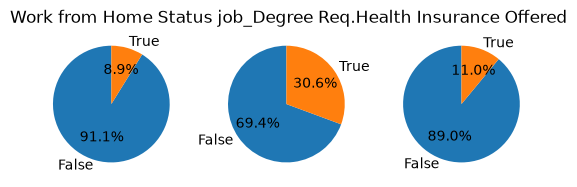

In [19]:
# Pie Chart

df['job_work_from_home'].value_counts().plot(kind='pie',startangle=90, autopct='%1.1f%%')          #Start angle adjusts the angle of the first slice
plt.title('Work from Home Status')                       #Percentage of each slice is displayed using autopct. Can specifcy the number of decimal places to display using %1f, %1.1f, %1.2f etc. F stands for a floating number
plt.ylabel("")                                     #To show the "%" symbol, you need a 2 "%" symbols at the end
plt.show()

fig, ax = plt.subplots(1,3)                          # 3 different pie charts

dict_column = {'job_work_from_home': 'Work from Home Status',                      #Value and what to provide as header of each pie chart
               'job_no_degree_mention': 'job_Degree Req.',
               'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate(dict_column.items()):       #Returns the tuple
    ax[i].pie(df[column].value_counts(),startangle=90, autopct='%1.1f%%', labels= ['False', 'True'])          #Start angle adjusts the angle of the first slice
    ax[i].set_title(title)
plt.show()

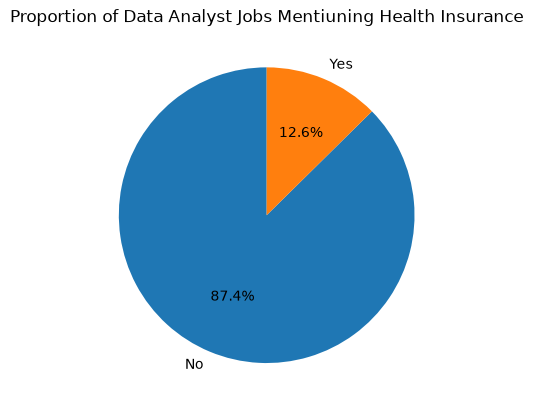

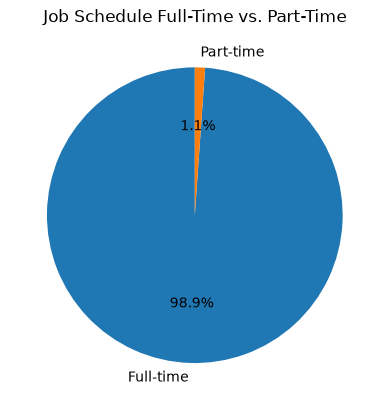

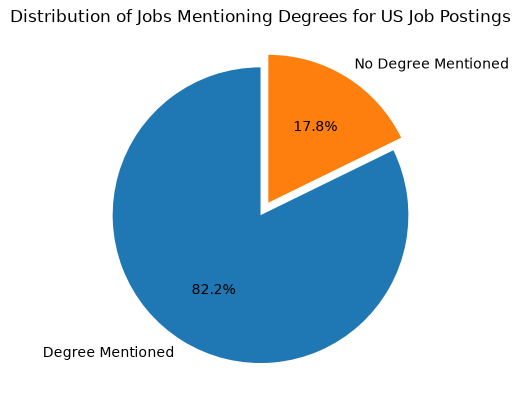

In [31]:
# PRACTICE PROBLEMS

df_DA = df[df['job_title_short'] == 'Data Analyst']
df_DA.value_counts('job_health_insurance').plot(kind = 'pie', startangle = 90, labels = ['No','Yes'], autopct = '%1.1f%%')
plt.title('Proportion of Data Analyst Jobs Mentiuning Health Insurance')
plt.show()

df_ft_pt = df[df['job_schedule_type'].isin(['Full-time', 'Part-time'])]
df_ft_pt.value_counts('job_schedule_type').plot(kind = 'pie', startangle = 90, autopct = '%1.1f%%')
plt.title('Job Schedule Full-Time vs. Part-Time')
plt.show()

df_US = df[df['job_country'] == 'United States']
df_US.value_counts('job_no_degree_mention').plot(kind = 'pie', labels = ['Degree Mentioned','No Degree Mentioned'],autopct = '%1.1f%%', startangle = 90, explode = (0,0.1))
plt.title('Distribution of Jobs Mentioning Degrees for US Job Postings')
plt.show()

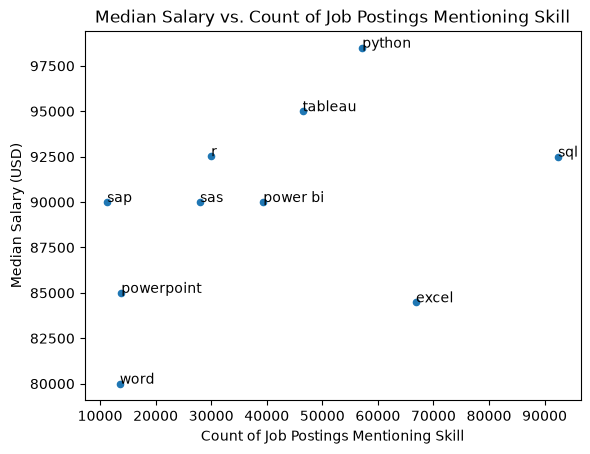

In [ ]:
# Scatterplots

# df.plot(kind = 'scatter', x = 'job_salary_in_usd', y = 'job_experience_required')   plotting by x and y coordinates

df_DA =df[df['job_title_short']=='Data Analyst']
df_exploded = df_DA.explode('job_skills')
df_exploded

#Group job skills to get the count and also for salry year average, we also eed to aggregate them by median. Lots of aggregation methods

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count = ('job_skills', 'count'), # Skill count is now the column name, and using job skills coloumn to count the number of skills. Count is the aggregation method
    median_salary = ('salary_year_avg', 'median')              #Same with median salary, but using the salary_year_avg column to get the median value of salaries for each skill
)             

skill_stats =skill_stats.sort_values(by= 'skill_count',ascending = False).head(10)               #Now we can sort and then graph
skill_stats.plot(kind = 'scatter', x = 'skill_count', y = 'median_salary')
plt.xlabel('Count of Job Postings Mentioning Skill')
plt.ylabel('Median Salary (USD)')
plt.title('Median Salary vs. Count of Job Postings Mentioning Skill')  #Unfortunately, Matplot lib doesnt make it easy to annotate the points. to do this, we use the for loop
for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)  
    # In this for loop, we are using the index of the skill_stats dataframe to get the skill name and then using the iloc method to get the x and y coordinates of each point. The plt.text method is used to annotate the points with the skill name.
plt.show()

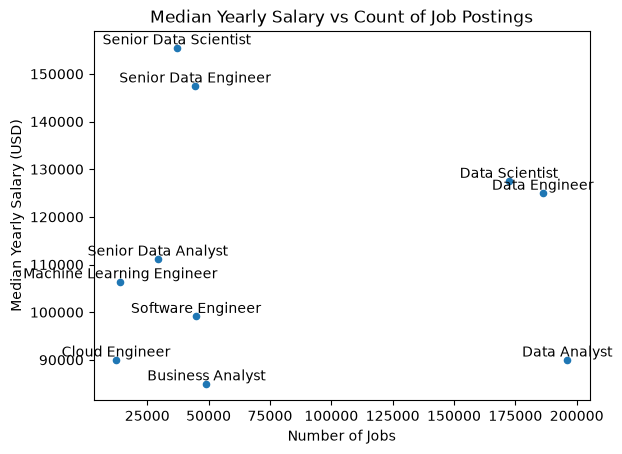

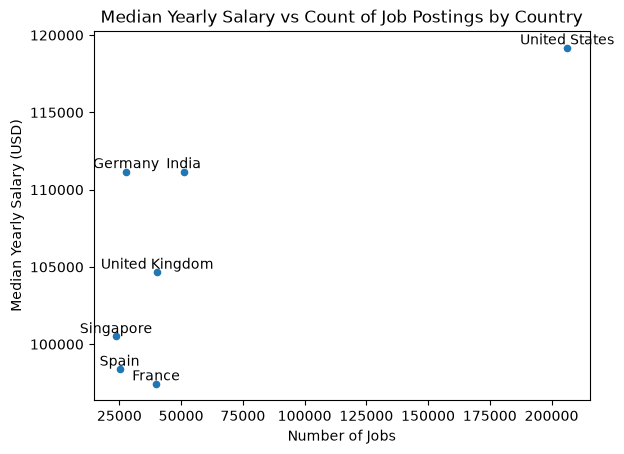

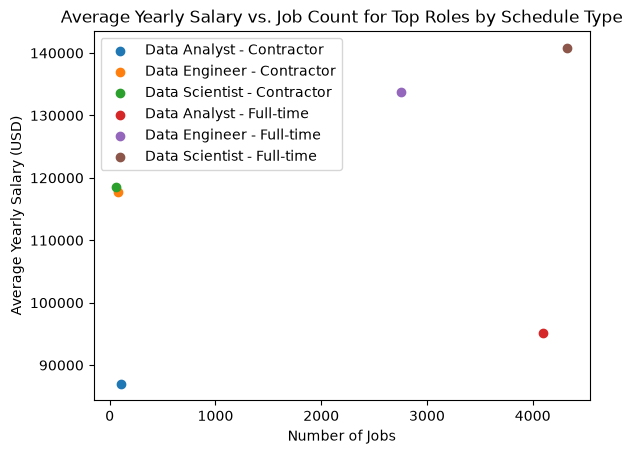

In [ ]:
# PRACTICE PROBLEMS
job_title_stats = df.groupby('job_title_short').agg(
    job_count = ('job_title_short', 'count'),
    median_salary_year_avg = ('salary_year_avg', 'median')        
).dropna()
job_title_stats.plot(kind='scatter', x='job_count', y='median_salary_year_avg')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings')
for i in range(len(job_title_stats)):
   job_count = job_title_stats['job_count'].iloc[i]
   mean_salary = job_title_stats['median_salary_year_avg'].iloc[i]
   job_title = job_title_stats.index[i]
   plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')
plt.show()

country_stats = df.groupby('job_country').agg(
    job_count = ('job_country', 'count'),
    median_salary_year_avg = ('salary_year_avg', 'median')        
).sort_values(by='job_count', ascending=False).head(7)
country_stats.plot(kind='scatter', x='job_count', y='median_salary_year_avg')
plt.xlabel('Number of Jobs')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Median Yearly Salary vs Count of Job Postings by Country')
for i in range(len(country_stats)):
   job_count = country_stats['job_count'].iloc[i]
   mean_salary = country_stats['median_salary_year_avg'].iloc[i]
   job_title = country_stats.index[i]
   plt.text(job_count, mean_salary, job_title, ha='center', va='bottom')
plt.show()

target_job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']  
us_jobs_df = df[                                                     # Filter US jobs for only full-time and part-time roles and specific job titles, then drop rows with missing salary data
   (df['job_country'] == 'United States') &
   (df['job_schedule_type'].isin(['Full-time', 'Contractor'])) &
   (df['job_title_short'].isin(target_job_titles))
].dropna(subset=['salary_year_avg']).copy()
stats = us_jobs_df.groupby(['job_schedule_type', 'job_title_short']).agg(              # Group by job schedule type and job title, calculate mean yearly salary and job count
   mean_salary_year_avg=('salary_year_avg', 'mean'),
   job_count=('job_title_short', 'count')
).dropna()
stats.reset_index(inplace=True)
stats['job_title_type'] = stats['job_title_short'] + ' - ' + stats['job_schedule_type']      # Combine title and type into one value for labels
for job_title_type in stats['job_title_type'].unique():
   subset = stats[stats['job_title_type'] == job_title_type]
   plt.scatter(subset['job_count'], subset['mean_salary_year_avg'], label=job_title_type)
plt.xlabel('Number of Jobs')
plt.ylabel('Average Yearly Salary (USD)')
plt.title('Average Yearly Salary vs. Job Count for Top Roles by Schedule Type')
plt.legend()
plt.show()




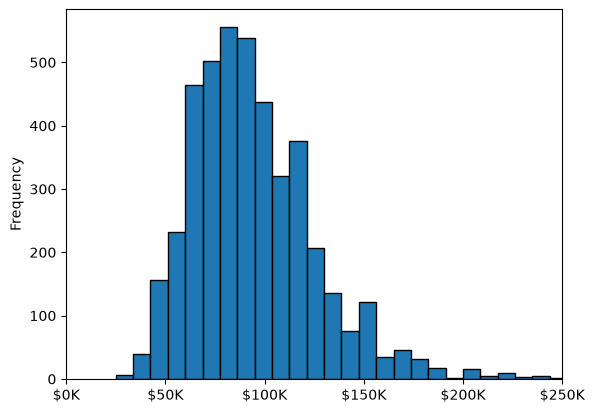

In [ ]:
# Histograms
#df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['salary_year_avg'].plot(kind='hist', bins = 40, edgecolor='black')          #Adding bins = 40 to make the histogram more granular. The default is 10 bins, which is too few for this data.
plt.xlim(0, 250000)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.show()

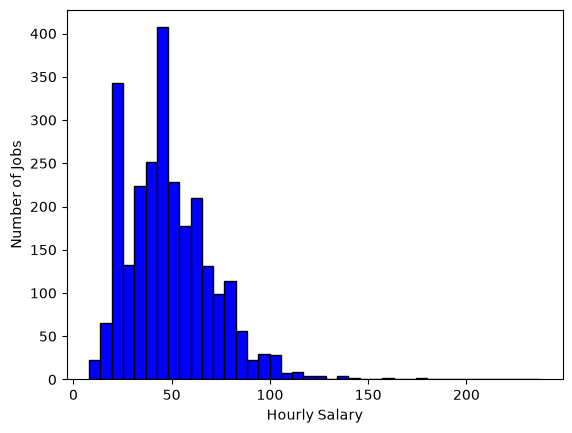

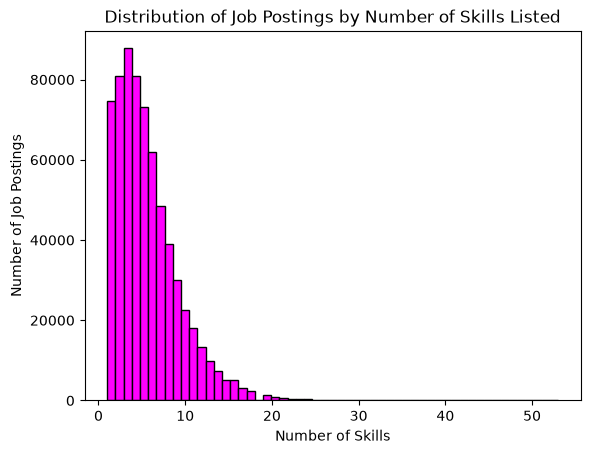

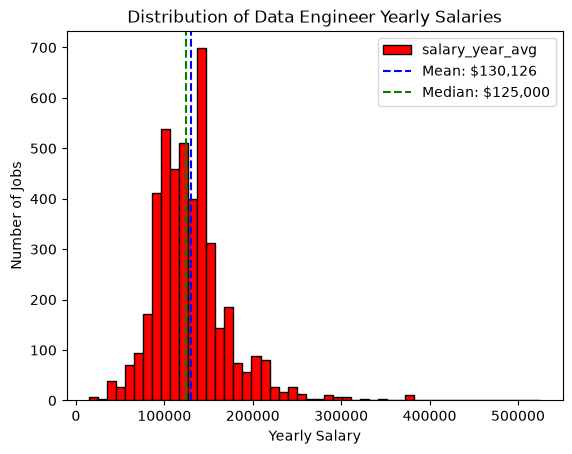

In [75]:
# Practice Problems

df_DS = df[df['job_title_short'] == 'Data Scientist']
df_DS['salary_hour_avg'].plot(kind = 'hist', bins = 40, color='blue', edgecolor = 'black')
plt.xlabel('Hourly Salary')
plt.ylabel('Number of Jobs')
plt.show()

df_skills = df.dropna(subset=['job_skills']).copy()
df_skills['num_skills'] = df_skills['job_skills'].apply(len)    
df_skills['num_skills'].plot(kind='hist', bins=55, color='magenta', edgecolor='black')
plt.xlabel('Number of Skills')
plt.ylabel('Number of Job Postings')
plt.title('Distribution of Job Postings by Number of Skills Listed')
plt.show()

df_DE = df[df['job_title_short'] == 'Data Engineer'].copy()
df_DE = df_DE.dropna(subset=['salary_year_avg'])
mean_salary = df_DE['salary_year_avg'].mean()
median_salary = df_DE['salary_year_avg'].median()
df_DE['salary_year_avg'].plot(kind='hist', bins=50, color='red', edgecolor='black')
plt.axvline(mean_salary, color='blue', linestyle='dashed', label=f'Mean: ${mean_salary:,.0f}')
plt.axvline(median_salary, color='green', linestyle='dashed', label=f'Median: ${median_salary:,.0f}')
plt.xlabel('Yearly Salary')
plt.ylabel('Number of Jobs')
plt.title('Distribution of Data Engineer Yearly Salaries')
plt.legend()
plt.show()


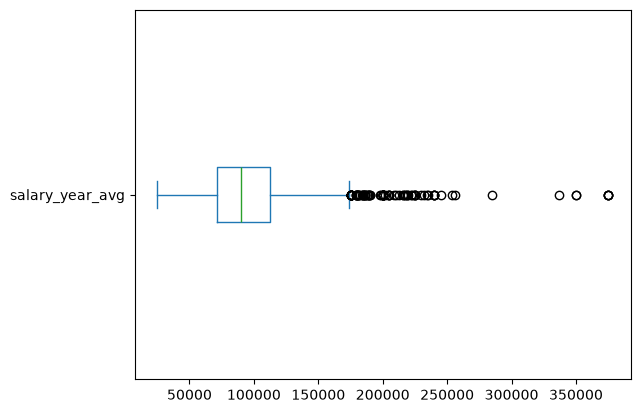

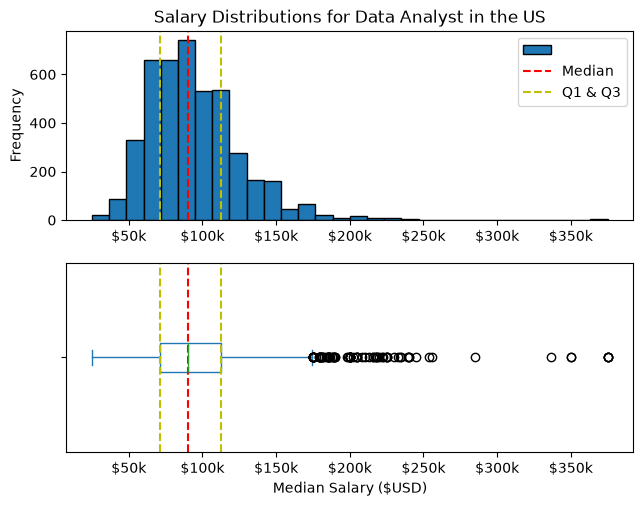

In [ ]:
# Box Plots
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])

df_DA_US['salary_year_avg'].plot(kind = 'box', vert = False)             #Basic box plot of the salary distribution for Data Analysts in the US



fig, ax = plt.subplots(2, 1)                                                      #Next lines of code lines up the box plot and histogram of the salary distribution for Data Analysts in the US
fig.tight_layout(h_pad=1)

df_DA_US['salary_year_avg'].plot(kind='hist', ax=ax[0], bins=30, edgecolor='black')                         
ax[0].set_title('Salary Distributions for Data Analyst in the US')
ax[0].set_xlabel('')
ax[0].set_ylabel('Frequency')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# lines
ax[0].axvline(df_DA_US['salary_year_avg'].median(), color='r', linestyle='--')
ax[0].axvline(df_DA_US['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[0].axvline(df_DA_US['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
ax[0].legend(['', 'Median', 'Q1 & Q3'])


df_DA_US['salary_year_avg'].plot(kind='box', ax=ax[1], vert=False)
ax[1].set_yticklabels('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: '${0:g}k'.format(x/1000)))
# lines
ax[1].axvline(df_DA_US['salary_year_avg'].median(), color='r', linestyle='--')
ax[1].axvline(df_DA_US['salary_year_avg'].quantile(0.25), color='y', linestyle='--')
ax[1].axvline(df_DA_US['salary_year_avg'].quantile(0.75), color='y', linestyle='--')
plt.show()

C:\Users\Toby Phan\AppData\Local\Temp\ipykernel_34500\14529499.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(job_list, label=job_titles, vert=False)


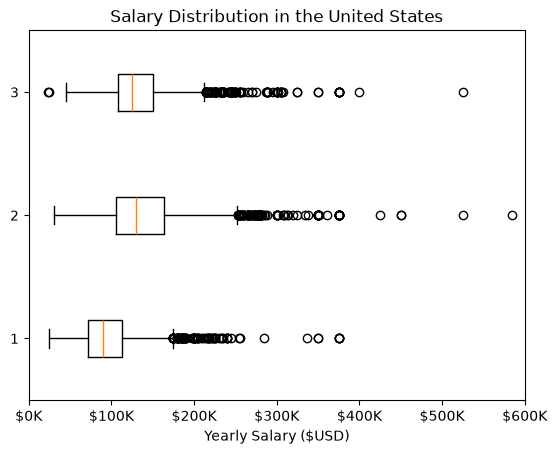

In [98]:
job_titles = ['Data Analyst', 'Data Scientist', 'Data Engineer']
df_US = df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()  #If the job titles are within the list of job titles I assigned
df_US = df_US.dropna(subset= ['salary_year_avg'])

 
job_list = [df_US[df_US['job_title_short'] == job_title]['salary_year_avg'] for job_title in job_titles]      #list of all different series values. ALso provide lables for each job title.   #We do list comprehenshion 
     
plt.boxplot(job_list, label=job_titles, vert=False)
plt.title('Salary Distribution in the United States')
plt.xlabel('Yearly Salary ($USD)')
ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
plt.xlim(0,600000)
plt.show()          



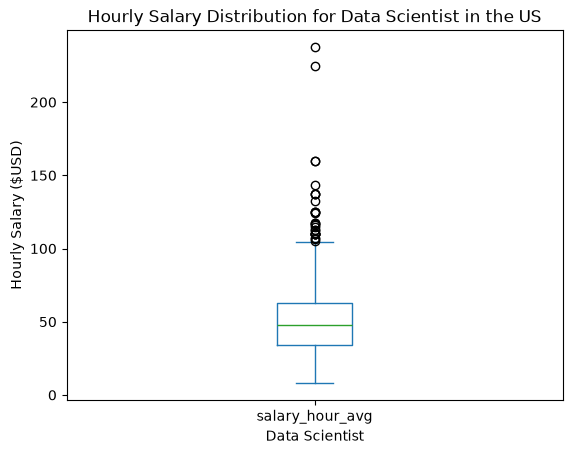

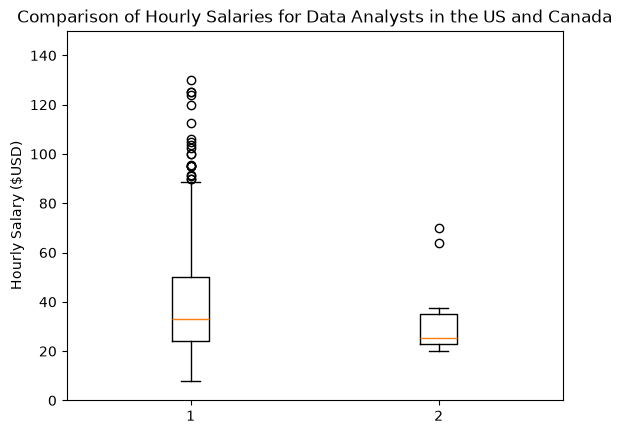

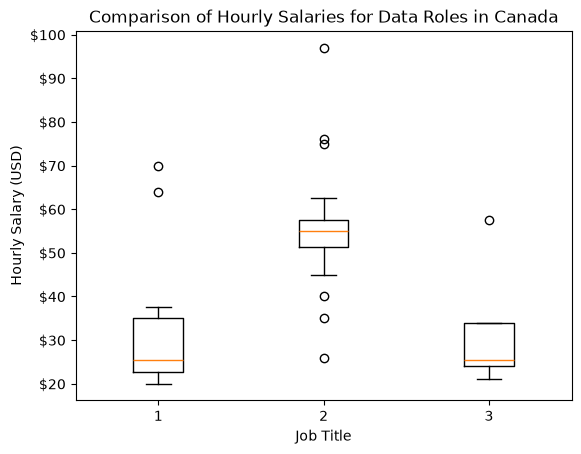

In [104]:
# PRACTICE PROBLEMS

df_DS_US = df[(df['job_title_short'] == 'Data Scientist') & (df['job_country'] == 'United States')].dropna(subset=['salary_hour_avg'])
df_DS_US['salary_hour_avg'].plot(kind='box')
plt.xlabel('Data Scientist')
plt.ylabel('Hourly Salary ($USD)')
plt.title('Hourly Salary Distribution for Data Scientist in the US')
plt.show()

countries = ['United States', 'Canada']
df_filtered = df[(df['job_country'].isin(countries)) & (df['job_title_short'] == 'Data Analyst')].dropna(subset=['salary_hour_avg'])
country_data = [df_filtered[df_filtered['job_country'] == country]['salary_hour_avg'] for country in countries]       # Get list of DataFrames for each country
plt.boxplot(country_data, label=countries)
plt.xlabel('')
plt.ylabel('Hourly Salary ($USD)')
plt.ylim(0, 150)
plt.title('Comparison of Hourly Salaries for Data Analysts in the US and Canada')
plt.show()

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_Canada = df[df['job_country'] == 'Canada'].dropna(subset=['salary_hour_avg'])
job_list = [df_Canada[df_Canada['job_title_short'] == job]['salary_hour_avg'] for job in job_titles]         # Filter out data
fig, ax = plt.subplots()
ax.boxplot(job_list, label=job_titles)
ax.set_xlabel('Job Title')
ax.set_ylabel('Hourly Salary (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y)}'))
ax.set_title('Comparison of Hourly Salaries for Data Roles in Canada')
plt.show()

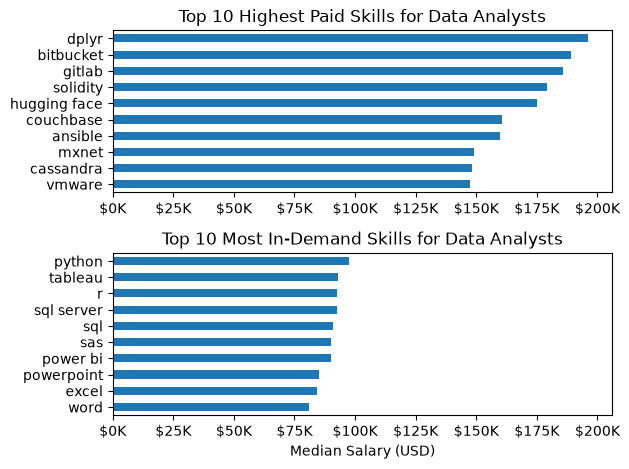

In [119]:
# EXERCISE: Skill Pay Analysis

df_DA_US = df[(df['job_title_short'] =='Data Analyst') & (df['job_country'] == 'United States')].copy().dropna(subset = 'salary_year_avg')
df_DA_US = df_DA_US.explode('job_skills')
df_DA_US[['salary_year_avg','job_skills']]

df_DA_US_grouped = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

#One dataframe with top 10 highest salaries and one with top 10 skills that have highest count with associated salary
df_DA_top_pay = df_DA_US_grouped.sort_values(by = 'median',ascending = False).head(10)
df_DA_skills = df_DA_US_grouped.sort_values(by = 'count',ascending=False).head(10).sort_values(by = 'median',ascending = False)

# Now we can plot
fig, ax = plt.subplots(2,1)
df_DA_top_pay.plot(kind = 'barh', y = 'median', ax = ax[0],legend = False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
df_DA_skills.plot(kind = 'barh', y = 'median', ax = ax[1],legend = False)
ax[1].invert_yaxis()
ax[1].set_xlim(ax[0].get_xlim())          #Axis from bottom graph are matched with top
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

fig.tight_layout()